In [15]:
# Menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Loading Dataset**

In [16]:
import pandas as pd

# Membaca file csv menggunakan pandas
df = pd.read_csv("/content/drive/MyDrive/Hisyam Wildan Alfath/Semester 7/Machine Learning/Pertemuan 6/Praktikum & Tugas Mandiri 06/data/drug200.csv")

# Cetak header data (5 baris data) dari file
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [18]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [19]:
df["Drug"].unique()

array(['DrugY', 'drugC', 'drugX', 'drugA', 'drugB'], dtype=object)

In [20]:
df["Drug"].value_counts()

,count
Drug,
DrugY,91
drugX,54
drugA,23
drugC,16
drugB,16


In [21]:
# Cek duplicate
df.duplicated().sum()

np.int64(0)

**Pemilihan Fitur**

In [22]:
# Fitur (X) tanpa kolom SkinThickness dan BloodPressure
X = df[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']]

# Kolom target (y)
y = df['Drug']

In [23]:
X.head()

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,F,HIGH,HIGH,25.355
1,47,M,LOW,HIGH,13.093
2,47,M,LOW,HIGH,10.114
3,28,F,NORMAL,HIGH,7.798
4,61,F,LOW,HIGH,18.043


In [24]:
y.head()

,Drug
0,DrugY
1,drugC
2,drugC
3,drugX
4,DrugY


In [25]:
# fitur kategorikal lain (Sex, BP, Cholesterol)
for col in ['Sex','BP', 'Cholesterol', 'Drug']:
    if col in df.columns:
        df[col] = df[col].astype('category').cat.codes

df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,0
1,47,1,1,0,13.093,3
2,47,1,1,0,10.114,3
3,28,0,2,0,7.798,4
4,61,0,1,0,18.043,0


In [33]:
from sklearn.preprocessing import LabelEncoder

# Membuat instance dari objek LabelEncoder
encoder = LabelEncoder()

# Melakukan iterasi pada setiap kolom non-numerik (object) di fitur X
# dan mengubahnya menjadi nilai numerik.
for col in X.select_dtypes(include='object').columns:
    X[col] = encoder.fit_transform(X[col])

# Mengubah label target (y) menjadi format numerik
y = encoder.fit_transform(y)

# Menampilkan lima baris pertama dari data fitur untuk verifikasi hasil
print("Setelah Encoding:")
display(X.head())

Setelah Encoding:


,Age,Sex,BP,Cholesterol,Na_to_K
0,23,0,0,0,25.355
1,47,1,1,0,13.093
2,47,1,1,0,10.114
3,28,0,2,0,7.798
4,61,0,1,0,18.043


**Split dan Bangun Model SVM**

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Membuat model SVM dengan kernel linear
model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

In [28]:
y_pred = model.predict(X_test)
# Akurasi
print(f"Akurasi: {accuracy_score(y_test, y_pred) * 100:.2f}%")
# Laporan klasifikasi
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))

Akurasi: 100.00%

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00        11

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



**Confusion Matrix**


Confusion Matrix:
 [[15  0  0  0  0]
 [ 0  6  0  0  0]
 [ 0  0  3  0  0]
 [ 0  0  0  5  0]
 [ 0  0  0  0 11]]


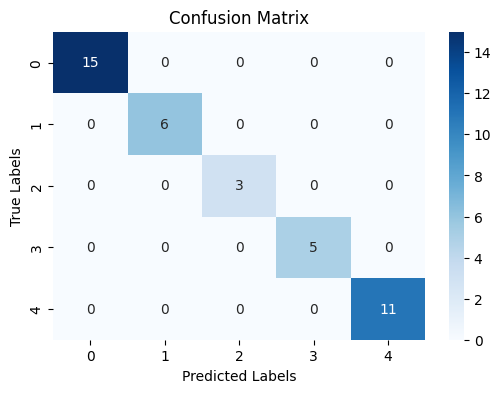

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Jika kamu tahu nama kelas (opsional, agar lebih informatif)
# misalnya: class_names = ['Negatif', 'Positif']
# maka tambahkan ke heatmap di bagian "xticklabels" dan "yticklabels"

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

**Visualisasi Hasil Model SVM**

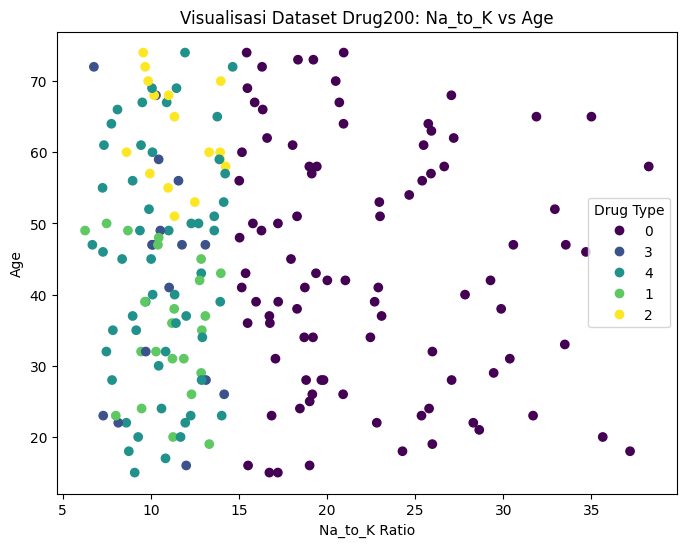

In [30]:
# Scatter plot
plt.figure(figsize=(8,6))
# Get the encoded values for coloring
encoded_drugs, drug_labels = pd.factorize(df['Drug'])
scatter = plt.scatter(df['Na_to_K'], df['Age'], c=encoded_drugs, cmap='viridis')

# Label dan judul
plt.xlabel('Na_to_K Ratio')
plt.ylabel('Age')
plt.title('Visualisasi Dataset Drug200: Na_to_K vs Age')

# Create legend handles and labels manually
legend_handles = scatter.legend_elements()[0]
# Map encoded values back to original drug names for legend labels
unique_encoded_drugs = sorted(list(set(encoded_drugs)))
legend_labels = [drug_labels[i] for i in unique_encoded_drugs]

plt.legend(handles=legend_handles, labels=legend_labels, title="Drug Type")

# Tampilkan plot
plt.show()

**3D Visualisasi Hasil Model SVM**

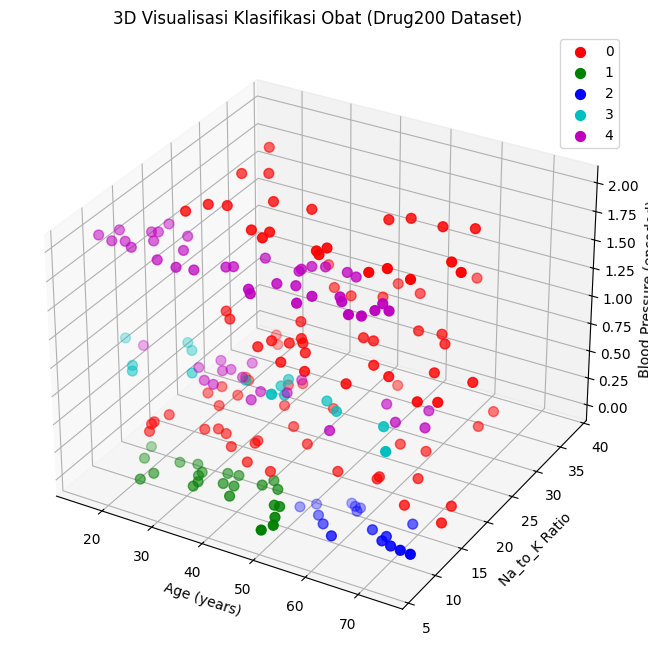

In [36]:
from sklearn.preprocessing import LabelEncoder
from mpl_toolkits.mplot3d import Axes3D

# Encode kolom kategori
le_drug = LabelEncoder()
df['DrugEncoded'] = le_drug.fit_transform(df['Drug'])

le_bp = LabelEncoder()
df['BPEncoded'] = le_bp.fit_transform(df['BP'])

# Siapkan figure 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Warna untuk tiap jenis obat
colors = ['r', 'g', 'b', 'c', 'm']
labels = le_drug.classes_

# Plot tiap jenis obat
for i, drug in enumerate(labels):
    subset = df[df['DrugEncoded'] == i]
    ax.scatter(
        subset['Age'],
        subset['Na_to_K'],
        subset['BPEncoded'],
        color=colors[i % len(colors)],
        label=drug,
        s=50
    )

# Label dan judul
ax.set_xlabel('Age (years)')
ax.set_ylabel('Na_to_K Ratio')
ax.set_zlabel('Blood Pressure (encoded)')
ax.set_title('3D Visualisasi Klasifikasi Obat (Drug200 Dataset)')
ax.legend()
plt.show()
